# Token-level TTR vs. LLM-judge degeneration labels

This notebook evaluates two token-level TTR decision rules against the LLM judge for each of the three dataset builds. The primary judge population is the set of rollouts that reached the 4096-token generation cap without a natural EOS; the termination-context study additionally uses every naturally terminated rollout.
Two questions are evaluated:

1. **Basic single-token rule:** a generation is degenerating if it contains at least one token with `repetition_score >= 0.8`; onset is the first such token.
2. **Sustained run-4 rule:** a generation is degenerating if it contains four consecutive tokens at or above the same threshold; onset is the first token of the first qualifying run.
3. **Comparison with the judge:** for each rule, measure completion-level detection and signed onset distance, then compare the two rules directly.
4. **Termination context:** measure how often the single-token TTR rule fires under natural EOS versus the token cap, and how much of each flagged rollout is above threshold.

The notebook is read-only with respect to the datasets.

## 1. Definitions

Let $r_t$ be the stored token-level `repetition_score`, computed by the labeling pipeline as $1-\mathrm{TTR}$ over bigrams in the 256-token window beginning at token $t$.

A token position is threshold-positive when

$$r_t \geq \tau.$$

Unlike an earlier version of this notebook, $\tau$ is no longer fixed at $0.8$ a priori. It is tuned once per dataset build by maximizing balanced accuracy on a deterministic calibration half of the prompts (Section 2.1), then applied unchanged to the disjoint test half for every table below -- the same calibration/test discipline used for Entropy and LRS elsewhere in this project (see `docs/analysis/metric_evaluation_unification_plan.md`). One $\tau$ is tuned per dataset build (on the single-token rule, see Section 2.1) and reused for both rules below, so the persistence window is the only thing that differs between them.

The **basic single-token rule** defines

$$o_1 = \min\left\{t:r_t\geq\tau\right\}, \qquad y_1=\mathbb{I}[o_1\text{ exists}].$$

The **sustained run-4 rule** defines

$$o_4 = \min\left\{t:r_t,r_{t+1},r_{t+2},r_{t+3}\geq\tau\right\}, \qquad y_4=\mathbb{I}[o_4\text{ exists}].$$

Undefined (`NaN`) scores are never threshold-positive and break a run. By construction, $y_4=1$ implies $y_1=1$, and whenever $o_4$ exists, $o_1\leq o_4$.

The LLM-judge binary reference is `is_degenerating`. For judge-positive completions, the judge onset $o_{\mathrm{LLM}}$ is the first generated-token position of the verbatim `onset_quote`. Quotes that cannot be located exactly are excluded from onset-distance statistics, but the corresponding binary verdict remains valid for completion-level detection.

The signed onset distance is defined as

$$d_j = o_{\mathrm{LLM}} - o_j, \qquad j\in\{1,4\}.$$

Thus $d_j>0$ means that the LLM judge places onset later than TTR, while $d_j<0$ means that the judge places onset earlier. Onset distance is only defined when the judge is positive, its quote is matched, and the corresponding TTR rule is positive.

**Population** (Section 2.1): positives are judge-confirmed truncated rollouts (`is_degenerating == True`); negatives are every `stop_reason == "eos"` rollout by definition (no judge call needed), plus the few judge-confirmed-negative truncated rollouts as hard negatives. This replaces an earlier version of this notebook that evaluated completion-level detection only on truncated rollouts, where negatives were scarce (a handful of judge-confirmed-negative rows) and specificity was correspondingly unstable.


In [1]:
import os
from pathlib import Path
import warnings

# The Apertus-8B tokenizer is already cached by dataset generation. Use the
# shared cache in offline mode so this notebook does not require network access.
SHARED_HF_CACHE = Path("/capstor/scratch/cscs/mdenegri/degeneration-probe/hf_cache")
if SHARED_HF_CACHE.exists():
    os.environ.setdefault("HF_HOME", str(SHARED_HF_CACHE))
    os.environ.setdefault("HF_HUB_CACHE", str(SHARED_HF_CACHE))
os.environ.setdefault("HF_HUB_OFFLINE", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from transformers import AutoTokenizer

from degeneration_probe.analysis import metric_eval as metric_eval_module
from degeneration_probe.utils.tokenization import find_string_in_tokens

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

DATA_ROOT = Path("/capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe")
DATASETS = {
    "Apertus-8B-Instruct": {
        "root": DATA_ROOT / "degeneration-dataset-apertus-8b-instruct",
        "tokenizer": "swiss-ai/Apertus-8B-Instruct-2509",
    },
    "Apertus 1.5 - capfilter-linear": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-capfilter-linear-it8816",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
    "Apertus 1.5 - SFT-256k": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-sft256k-4200",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
}

JUDGE_BACKEND = "claude_agent_sdk"
# tau is tuned per dataset build over this grid (Section 2.1), replacing the
# formerly-fixed TTR_THRESHOLD = 0.8.
TAU_CANDIDATES = [round(t, 2) for t in np.arange(0.50, 0.96, 0.05)]
MIN_CONSECUTIVE = 4
EXPECTED_MAX_TOKENS = 4096
KEY = ["prompt_id", "rollout_idx"]


W0722 10:27:38.488000 67259 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0722 10:27:38.595000 67259 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


## 2. Load and validate the current truncated-rollout sample

Judge result files may retain successfully judged rows from an older calibration sample. To avoid mixing populations, the analysis starts from the current `calibration_sample.parquet`, keeps only `stratum == "truncated"`, and inner-joins current successful judge results. It then joins generation and TTR-label shards by `(prompt_id, rollout_idx)`.

This gives the population used for onset localization below (it needs `generated_token_ids` to search for the judge's `onset_quote`, so it stays restricted to truncated, judged rollouts). Section 2.1 builds a second, larger population -- covering every rollout, including natural-EOS ones -- for completion-level detection and threshold tuning.


In [2]:
def read_domain_shards(root, kind, columns):
    frames = []
    for path in sorted((root / kind).glob("*/shard_*.parquet")):
        frame = pd.read_parquet(path, columns=columns)
        frame["shard_domain"] = path.parent.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No {kind} shards found below {root}")
    return pd.concat(frames, ignore_index=True)


def load_evaluation_population(root):
    sample_path = root / "llm_judge/calibration_sample.parquet"
    judge_path = root / f"llm_judge/results_{JUDGE_BACKEND}.parquet"

    sample = pd.read_parquet(sample_path)
    sample = sample[sample["stratum"].eq("truncated")].copy()
    judge_all = pd.read_parquet(judge_path)
    judge = judge_all[judge_all["status"].eq("ok")].copy()

    assert not sample.duplicated(KEY).any(), "Duplicate keys in current calibration sample"
    assert not judge.duplicated(KEY).any(), "Duplicate keys in successful judge results"

    # Starting from the current sample deliberately drops stale judge rows.
    population = sample.merge(
        judge[KEY + ["is_degenerating", "onset_quote", "confidence"]],
        on=KEY, how="inner", validate="one_to_one",
    )

    generations = read_domain_shards(
        root, "generations",
        KEY + ["generated_token_ids", "num_tokens", "stop_reason"],
    )
    labels = read_domain_shards(root, "labels", KEY + ["repetition_score"])
    assert not generations.duplicated(KEY).any(), "Duplicate generation keys"
    assert not labels.duplicated(KEY).any(), "Duplicate label keys"

    population = population.merge(
        generations[KEY + ["generated_token_ids", "num_tokens", "stop_reason"]],
        on=KEY, how="left", validate="one_to_one",
    ).merge(
        labels[KEY + ["repetition_score"]],
        on=KEY, how="left", validate="one_to_one",
    )

    assert population["generated_token_ids"].notna().all(), "Missing generation rows"
    assert population["repetition_score"].notna().all(), "Missing TTR label rows"
    assert population["stop_reason"].eq("length").all(), "Sample contains a natural EOS rollout"
    assert population["num_tokens"].eq(EXPECTED_MAX_TOKENS).all(), "Sample contains a non-4096-token rollout"
    assert all(
        len(ids) == len(scores) == n
        for ids, scores, n in zip(
            population["generated_token_ids"],
            population["repetition_score"],
            population["num_tokens"],
        )
    ), "Token IDs and TTR labels are not aligned"

    coverage = {
        "sample_truncated": len(sample),
        "judge_ok_in_current_sample": len(population),
        "judge_coverage": len(population) / len(sample) if len(sample) else np.nan,
        "stale_or_other_judge_ok_excluded": len(judge) - len(population),
    }
    return population, coverage


populations = {}
coverage_rows = []
for model, spec in DATASETS.items():
    population, coverage = load_evaluation_population(spec["root"])
    populations[model] = population
    coverage_rows.append({"dataset_build": model, **coverage})

coverage_df = pd.DataFrame(coverage_rows).set_index("dataset_build")
display(coverage_df.style.format({"judge_coverage": "{:.1%}"}))

,sample_truncated,judge_ok_in_current_sample,judge_coverage,stale_or_other_judge_ok_excluded
dataset_build,,,,
Apertus-8B-Instruct,890,827,92.9%,97
Apertus 1.5 - capfilter-linear,1348,1278,94.8%,1266
Apertus 1.5 - SFT-256k,1193,1111,93.1%,0


## 2.1 Unified population and threshold calibration

Completion-level detection above evaluated TTR only on truncated rollouts, where negatives are scarce: a handful of judge-confirmed-negative rows per dataset build, so precision is meaningful but specificity is unstable. This section extends the population to every rollout, including natural-EOS ones, on the definitional grounds already established: a `stop_reason == "eos"` rollout is treated as negative without a judge call, since sustained repetition essentially never lets a model stop naturally (Section 8 quantifies this directly). Judge-confirmed-negative truncated rollouts are kept too, as hard negatives.

A deterministic prompt-hash split (`degeneration_probe.analysis.metric_eval.prompt_split`, shared with the Entropy and LRS notebooks) divides this population into a calibration half, used only to pick $\tau$, and a disjoint test half, used for every table and plot in Sections 3, 5, 6, and 7. $\tau$ is chosen by maximizing balanced accuracy of the **single-token** rule on calibration and reused for the run-4 rule (varying only the persistence window between the two), so the $y_4 \Rightarrow y_1$ relationship (Section 7) still holds by construction.


In [3]:
def load_raw_judge_frames(root):
    sample = pd.read_parquet(root / "llm_judge/calibration_sample.parquet")
    judge = pd.read_parquet(root / f"llm_judge/results_{JUDGE_BACKEND}.parquet")
    return sample, judge


def load_full_repetition_population(root):
    """Every rollout (eos and length alike), with its full per-token
    repetition_score array and a rollout-level max (used for the ROC/PR
    sweep, where a continuous score is needed rather than a boolean flag)."""
    generations = read_domain_shards(root, "generations", KEY + ["num_tokens", "stop_reason"])
    labels = read_domain_shards(root, "labels", KEY + ["repetition_score"])
    assert not generations.duplicated(KEY).any(), "Duplicate generation keys"
    assert not labels.duplicated(KEY).any(), "Duplicate label keys"
    population = generations.merge(
        labels.drop(columns=["shard_domain"]), on=KEY, how="inner", validate="one_to_one",
    )
    assert len(population) == len(generations) == len(labels), "Generation/label key mismatch"
    assert population["stop_reason"].isin(["eos", "length"]).all()
    population = population.rename(columns={"shard_domain": "domain"})
    population["max_repetition_score"] = population["repetition_score"].apply(
        lambda scores: float(np.nanmax(scores)) if np.any(np.isfinite(scores)) else np.nan
    )
    return population


full_populations = {}
unified_populations = {}
for model, spec in DATASETS.items():
    full_populations[model] = load_full_repetition_population(spec["root"])
    sample_df, judge_df = load_raw_judge_frames(spec["root"])
    unified = metric_eval_module.build_unified_population(
        full_populations[model], sample_df, judge_df, backend=None,
    )
    unified = unified.merge(
        full_populations[model][KEY + ["repetition_score", "max_repetition_score"]],
        on=KEY, how="left",
    )
    unified_populations[model] = unified

    n_calib = int((unified["evaluation_split"] == "calibration").sum())
    n_test = int((unified["evaluation_split"] == "test").sum())
    print(
        f"{model}: {len(unified)} rows "
        f"({int(unified['is_positive'].sum())} positive) -- "
        f"calibration: {n_calib}, test: {n_test}"
    )


Apertus-8B-Instruct: 36237 rows (819 positive) -- calibration: 18649, test: 17588


Apertus 1.5 - capfilter-linear: 36230 rows (1272 positive) -- calibration: 18636, test: 17594


Apertus 1.5 - SFT-256k: 36218 rows (1033 positive) -- calibration: 18628, test: 17590


In [4]:
def first_ttr_run_onset(scores, threshold, min_consecutive=MIN_CONSECUTIVE):
    values = np.asarray(scores, dtype=float)
    above = np.isfinite(values) & (values >= threshold)
    if len(above) < min_consecutive:
        return None
    run_lengths = np.convolve(
        above.astype(np.int8),
        np.ones(min_consecutive, dtype=np.int8),
        mode="valid",
    )
    starts = np.flatnonzero(run_lengths == min_consecutive)
    return int(starts[0]) if len(starts) else None


# Small deterministic checks, including equality at the threshold and a NaN break.
assert first_ttr_run_onset([0.1, 0.8, 0.9, 0.8, 1.0, 0.2], threshold=0.8) == 1
assert first_ttr_run_onset([0.8, 0.9, np.nan, 0.9, 0.9, 0.9, 0.9], threshold=0.8) == 3
assert first_ttr_run_onset([0.8, 0.8, 0.8, 0.79], threshold=0.8) is None
assert first_ttr_run_onset([0.1, 0.8, 0.9], threshold=0.8, min_consecutive=1) == 1
assert first_ttr_run_onset([np.nan, 0.79, 0.81], threshold=0.8, min_consecutive=1) == 2
assert first_ttr_run_onset([np.nan, 0.79], threshold=0.8, min_consecutive=1) is None


In [5]:
def rule_flag(scores, threshold, min_consecutive):
    return first_ttr_run_onset(scores, threshold=threshold, min_consecutive=min_consecutive) is not None


TAU = {}
for model, unified in unified_populations.items():
    calibration = unified[unified["evaluation_split"] == "calibration"]
    best_tau, best_balanced_accuracy = None, -1.0
    for tau in TAU_CANDIDATES:
        flags = calibration["repetition_score"].apply(
            lambda scores: rule_flag(scores, tau, min_consecutive=1)
        )
        metrics = metric_eval_module.confusion_metrics(calibration["is_positive"], flags)
        if metrics["balanced_accuracy"] >= best_balanced_accuracy:
            best_balanced_accuracy = metrics["balanced_accuracy"]
            best_tau = tau
    TAU[model] = best_tau
    print(f"{model}: tuned tau (calibration only, single-token rule) = {best_tau}")


Apertus-8B-Instruct: tuned tau (calibration only, single-token rule) = 0.55


Apertus 1.5 - capfilter-linear: tuned tau (calibration only, single-token rule) = 0.65


Apertus 1.5 - SFT-256k: tuned tau (calibration only, single-token rule) = 0.6


## 3. Sustained run-4 TTR: completion-level study

The implementation below returns the first start index of four consecutive finite scores greater than or equal to the tuned $\tau$ (Section 2.1). A completion is flagged exactly when this onset is defined. Completion-level detection is reported on the unified population's test split (Section 2.1); onset comparisons below (Section 6) still use the truncated-only population, since onset distance is only defined where the judge locates a quote.


In [6]:
for model, population in populations.items():
    tau = TAU[model]
    population["ttr_run4_onset"] = population["repetition_score"].apply(
        lambda scores: first_ttr_run_onset(scores, threshold=tau)
    )
    population["ttr_run4_flag"] = population["ttr_run4_onset"].notna()
    population["is_degenerating"] = population["is_degenerating"].astype(bool)
    print(
        f"{model} (tau={tau}): {population['ttr_run4_flag'].sum()}/{len(population)} "
        f"TTR-positive ({population['ttr_run4_flag'].mean():.1%}) on the truncated-only population"
    )


Apertus-8B-Instruct (tau=0.55): 631/827 TTR-positive (76.3%) on the truncated-only population
Apertus 1.5 - capfilter-linear (tau=0.65): 1145/1278 TTR-positive (89.6%) on the truncated-only population
Apertus 1.5 - SFT-256k (tau=0.6): 908/1111 TTR-positive (81.7%) on the truncated-only population


### 3.1 Completion-level detection

TTR is the prediction and the LLM judge is the reference. A true positive is therefore a rollout flagged by both. Precision answers: *when TTR flags a rollout, how often does the judge agree?* Recall answers: *among rollouts judged degenerating, how often does the sustained TTR rule flag them?* Specificity is now meaningful (not just reported for completeness): the population includes every natural-EOS rollout as a real negative, not just the handful of judge-confirmed-negative truncated rows.

Reported on the test split only (Section 2.1); domains below `metric_eval.MIN_POSITIVES_TEST` positive test rollouts are shown but excluded from the macro-average, same convention as the LRS study in `inspect_dataset.ipynb`.


In [7]:
run4_per_domain = {}
run4_aggregate = {}
for model, unified in unified_populations.items():
    tau = TAU[model]
    test = unified[unified["evaluation_split"] == "test"].copy()
    test["ttr_run4_flag"] = test["repetition_score"].apply(
        lambda scores: rule_flag(scores, tau, min_consecutive=MIN_CONSECUTIVE)
    )

    per_domain = metric_eval_module.per_domain_table(test["is_positive"], test["ttr_run4_flag"], test["domain"])
    macro = metric_eval_module.macro_average_row(per_domain).rename("ALL domains (macro-average)")
    pooled = pd.Series(
        metric_eval_module.pooled_row(test["is_positive"], test["ttr_run4_flag"]), name="ALL domains (pooled)"
    )
    run4_per_domain[model] = per_domain
    run4_aggregate[model] = pd.DataFrame([macro, pooled])

    print(f"{model} (tau={tau}, run-4 rule) -- completion-level, test split")
    display(run4_aggregate[model])

run4_completion_metrics_df = pd.concat(
    {model: agg.loc["ALL domains (pooled)"] for model, agg in run4_aggregate.items()}, axis=1
).T
run4_completion_metrics_df.index.name = "dataset_build"


Apertus-8B-Instruct (tau=0.55, run-4 rule) -- completion-level, test split


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.156753,0.717401,0.839528,0.778464,0.276957,0.835441,4.0,11608.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.121071,0.728900,0.879688,0.804294,0.263529,0.876336,NaN,17588.0,285.0,2069.0,106.0,15128.0


Apertus 1.5 - capfilter-linear (tau=0.65, run-4 rule) -- completion-level, test split


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.329800,0.896651,0.920574,0.908613,0.494297,0.919653,5.0,14444.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.307738,0.898276,0.931116,0.914696,0.502153,0.930033,NaN,17594.0,521.0,1172.0,59.0,15842.0


Apertus 1.5 - SFT-256k (tau=0.6, run-4 rule) -- completion-level, test split


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.299584,0.786939,0.870843,0.828891,0.376329,0.869969,6.0,17430.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.150282,0.827801,0.868132,0.847966,0.317362,0.867027,NaN,17590.0,399.0,2256.0,83.0,14852.0


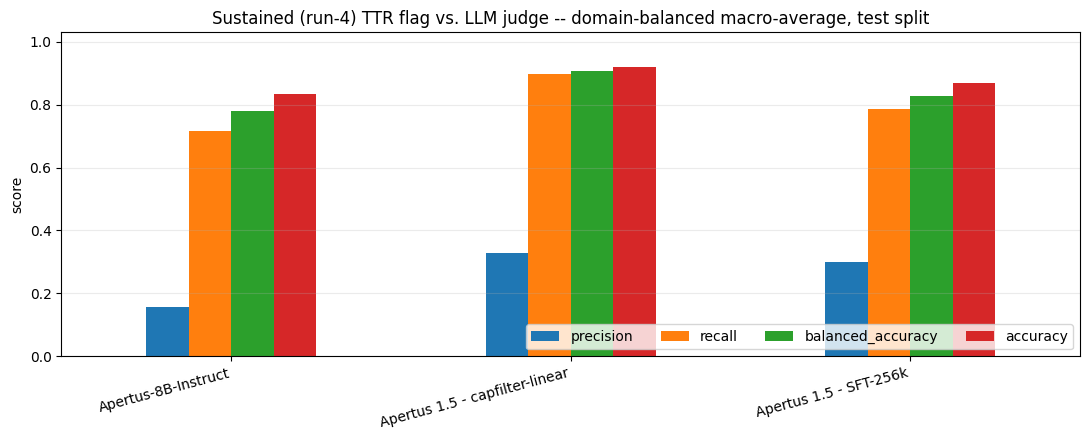

In [8]:
plot_metrics = ["precision", "recall", "balanced_accuracy", "accuracy"]
macro_plot_df = pd.concat(
    {model: agg.loc["ALL domains (macro-average)", plot_metrics] for model, agg in run4_aggregate.items()}, axis=1
).T
ax = macro_plot_df.plot.bar(figsize=(11, 4.5), ylim=(0, 1.03))
ax.set_ylabel("score")
ax.set_xlabel("")
ax.set_title("Sustained (run-4) TTR flag vs. LLM judge -- domain-balanced macro-average, test split")
ax.legend(loc="lower right", ncol=4)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### 3.2 Per-domain run-4 completion-level results

Domain-level rows with very few judge-positive examples can have unstable precision, recall, or MCC. `n`, TP/FP/FN/TN are shown alongside every metric, and the `insufficient` column marks domains below `metric_eval.MIN_POSITIVES_TEST` test-side positive rollouts -- these are excluded from the macro-average above (Section 3.1), not silently hidden here.


In [9]:
for model, per_domain in run4_per_domain.items():
    print(model)
    display(per_domain)


Apertus-8B-Instruct


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,8,46,0,106,0.148148,1.000000,0.697368,0.848684,0.321425,0.712500,True
codeforces,2830,7,217,0,2606,0.031250,1.000000,0.923131,0.961566,0.169847,0.923322,True
deepmath_103k,2770,48,684,12,2026,0.065574,0.800000,0.747601,0.773801,0.180787,0.748736,False
if_sft_data_verified,2738,89,281,46,2322,0.240541,0.659259,0.892048,0.775653,0.349145,0.880570,False
llama_nemotron,3020,39,157,26,2798,0.198980,0.600000,0.946870,0.773435,0.322151,0.939404,False
medical_o1,2990,0,7,0,2983,0.000000,NaN,0.997659,0.997659,NaN,0.997659,True
numinamath_1_5,3080,94,677,22,2287,0.121920,0.810345,0.771592,0.790969,0.255744,0.773052,False


Apertus 1.5 - capfilter-linear


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,8,66,1,85,0.108108,0.888889,0.562914,0.725901,0.208782,0.581250,True
codeforces,2830,38,136,3,2653,0.218391,0.926829,0.951237,0.939033,0.436772,0.950883,False
deepmath_103k,2770,33,400,5,2332,0.076212,0.868421,0.853587,0.861004,0.231260,0.853791,False
if_sft_data_verified,2746,175,103,32,2436,0.629496,0.845411,0.959433,0.902422,0.704422,0.950838,False
llama_nemotron,3020,56,97,7,2860,0.366013,0.888889,0.967196,0.928043,0.557896,0.965563,False
medical_o1,2990,5,2,1,2982,0.714286,0.833333,0.999330,0.916332,0.771025,0.998997,True
numinamath_1_5,3078,206,368,10,2494,0.358885,0.953704,0.871419,0.912561,0.541137,0.877193,False


Apertus 1.5 - SFT-256k


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,8,82,0,70,0.088889,1.000000,0.460526,0.730263,0.202326,0.487500,True
codeforces,2830,47,307,6,2470,0.132768,0.886792,0.889449,0.888121,0.318087,0.889399,False
deepmath_103k,2770,63,802,3,1902,0.072832,0.954545,0.703402,0.828974,0.216527,0.709386,False
if_sft_data_verified,2742,108,162,23,2449,0.400000,0.824427,0.937955,0.881191,0.545765,0.932531,False
llama_nemotron,3020,43,191,7,2779,0.183761,0.860000,0.935690,0.897845,0.379760,0.934437,False
medical_o1,2990,13,2,32,2943,0.866667,0.288889,0.999321,0.644105,0.496671,0.988629,False
numinamath_1_5,3078,117,710,12,2239,0.141475,0.906977,0.759240,0.833109,0.301167,0.765432,False


### 3.3 Threshold-free ROC/PR (shared continuous score)

Both rules threshold the same underlying per-token score; the persistence window (1 vs. 4) only changes how a crossing is turned into a binary flag, not the score itself. As a sanity check that the calibrated $\tau$ (Section 2.1) was not a lucky pick, this sweeps every possible cutoff of each rollout's **maximum** `repetition_score` (the natural rollout-level continuous summary of the same signal) and reports the resulting ROC/PR curves and AUC/average-precision, computed on the test split only.


Apertus-8B-Instruct: ROC AUC = 0.852, average precision = 0.400


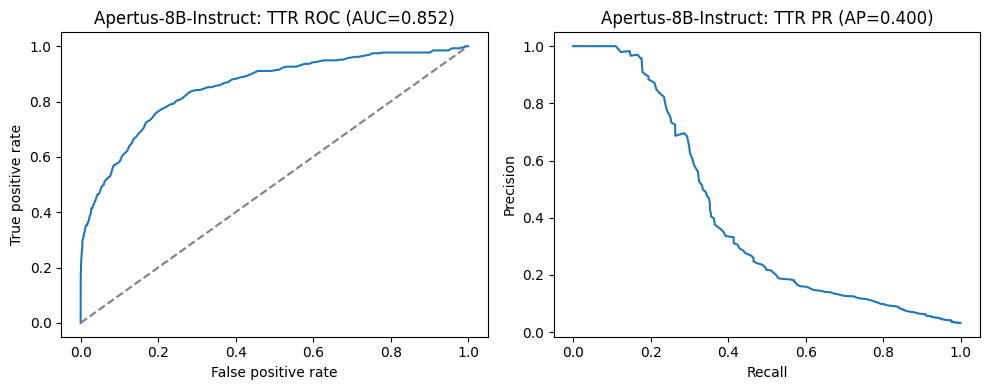

Apertus 1.5 - capfilter-linear: ROC AUC = 0.951, average precision = 0.730


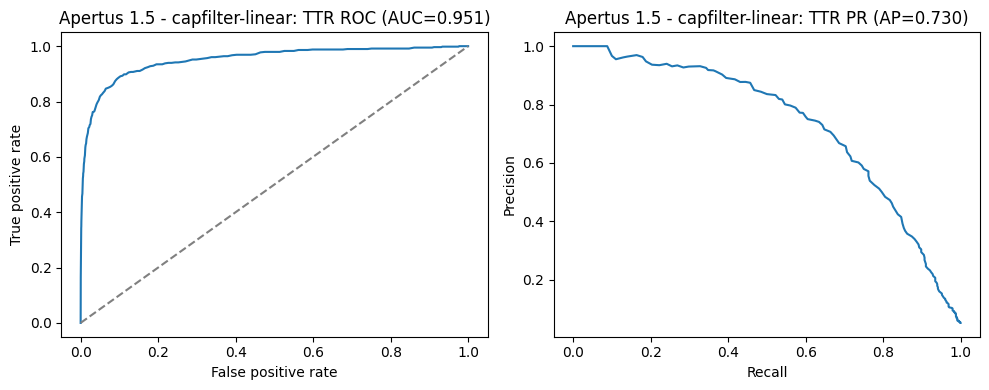

Apertus 1.5 - SFT-256k: ROC AUC = 0.894, average precision = 0.568


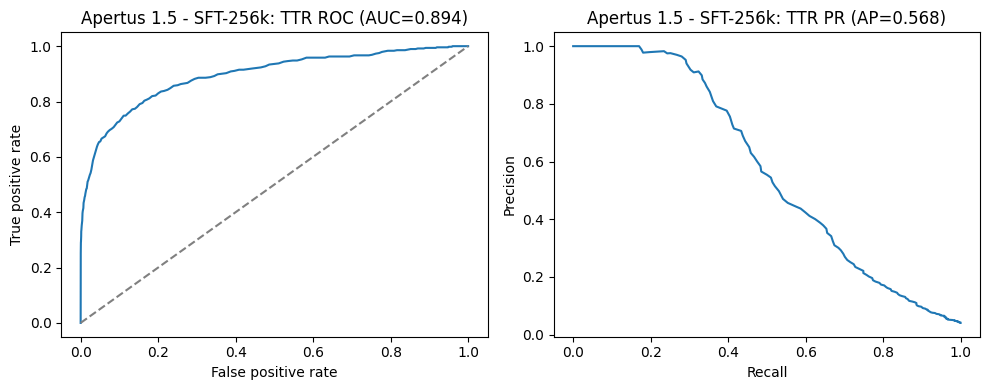

In [10]:
for model, unified in unified_populations.items():
    test = unified[unified["evaluation_split"] == "test"]
    curve = metric_eval_module.roc_pr_curve(test["max_repetition_score"], test["is_positive"])
    print(f"{model}: ROC AUC = {curve['roc_auc']:.3f}, average precision = {curve['average_precision']:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(curve["roc"]["fpr"], curve["roc"]["tpr"])
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"{model}: TTR ROC (AUC={curve['roc_auc']:.3f})")

    axes[1].plot(curve["pr"]["recall"], curve["pr"]["precision"])
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{model}: TTR PR (AP={curve['average_precision']:.3f})")

    plt.tight_layout()
    plt.show()


## 4. Locate LLM-judge onset quotes once for both studies

The quote is searched in the original generated token IDs using the tokenizer associated with each model build. The resulting token index is directly comparable with the index of `repetition_score`, because both are aligned to `generated_token_ids`.

In [11]:
_tokenizer_cache = {}


def get_tokenizer(name):
    if name not in _tokenizer_cache:
        kwargs = {"local_files_only": True}
        if not Path(name).exists() and SHARED_HF_CACHE.exists():
            kwargs["cache_dir"] = str(SHARED_HF_CACHE)
        _tokenizer_cache[name] = AutoTokenizer.from_pretrained(name, **kwargs)
    return _tokenizer_cache[name]


def locate_onset_quote(quote, generated_token_ids, tokenizer):
    if not isinstance(quote, str) or not quote:
        return np.nan
    tokens = torch.as_tensor([int(token) for token in generated_token_ids])
    try:
        return int(find_string_in_tokens(quote, tokens, tokenizer).start)
    except (AssertionError, ValueError):
        return np.nan


def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator else np.nan


quote_coverage_rows = []
for model, population in populations.items():
    tokenizer = get_tokenizer(DATASETS[model]["tokenizer"])
    positive = population["is_degenerating"]
    population["llm_onset"] = np.nan
    population.loc[positive, "llm_onset"] = [
        locate_onset_quote(quote, token_ids, tokenizer)
        for quote, token_ids in zip(
            population.loc[positive, "onset_quote"],
            population.loc[positive, "generated_token_ids"],
        )
    ]
    n_positive = int(positive.sum())
    n_quote_present = int(population.loc[positive, "onset_quote"].notna().sum())
    n_quote_matched = int(population.loc[positive, "llm_onset"].notna().sum())
    quote_coverage_rows.append({
        "dataset_build": model,
        "judge_positive": n_positive,
        "quote_present": n_quote_present,
        "quote_matched": n_quote_matched,
        "match_rate_among_judge_positive": safe_ratio(n_quote_matched, n_positive),
    })

quote_coverage_df = pd.DataFrame(quote_coverage_rows).set_index("dataset_build")
display(quote_coverage_df.style.format({"match_rate_among_judge_positive": "{:.1%}"}))


,judge_positive,quote_present,quote_matched,match_rate_among_judge_positive
dataset_build,,,,
Apertus-8B-Instruct,819,819,818,99.9%
Apertus 1.5 - capfilter-linear,1272,1272,1270,99.8%
Apertus 1.5 - SFT-256k,1033,1033,1033,100.0%


## 5. Basic single-token TTR study

This is the direct interpretation of a token-level score: a token is degenerating when `repetition_score >= tau` (the same tuned $\tau$ as Section 3); a generation is degenerating if and only if it contains at least one such token; onset is the first threshold-positive token. Equivalently, this is the same run detector used above with `min_consecutive=1` -- the rule $\tau$ was tuned against (Section 2.1).


In [12]:
single_per_domain = {}
single_aggregate = {}
for model, population in populations.items():
    tau = TAU[model]
    population["ttr_single_onset"] = population["repetition_score"].apply(
        lambda scores: first_ttr_run_onset(scores, threshold=tau, min_consecutive=1)
    )
    population["ttr_single_flag"] = population["ttr_single_onset"].notna()

    unified = unified_populations[model]
    test = unified[unified["evaluation_split"] == "test"].copy()
    test["ttr_single_flag"] = test["repetition_score"].apply(
        lambda scores: rule_flag(scores, tau, min_consecutive=1)
    )
    per_domain = metric_eval_module.per_domain_table(test["is_positive"], test["ttr_single_flag"], test["domain"])
    macro = metric_eval_module.macro_average_row(per_domain).rename("ALL domains (macro-average)")
    pooled = pd.Series(
        metric_eval_module.pooled_row(test["is_positive"], test["ttr_single_flag"]), name="ALL domains (pooled)"
    )
    single_per_domain[model] = per_domain
    single_aggregate[model] = pd.DataFrame([macro, pooled])

    print(f"{model} (tau={tau}, single-token rule) -- completion-level, test split")
    display(single_aggregate[model])

print("Per-domain completion-level metrics: basic single-token rule")
for model, per_domain in single_per_domain.items():
    print(model)
    display(per_domain)

single_completion_metrics_df = pd.concat(
    {model: agg.loc["ALL domains (pooled)"] for model, agg in single_aggregate.items()}, axis=1
).T
single_completion_metrics_df.index.name = "dataset_build"


Apertus-8B-Instruct (tau=0.55, single-token rule) -- completion-level, test split


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.154429,0.723420,0.835781,0.779600,0.275415,0.831991,4.0,11608.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.119434,0.734015,0.876955,0.805485,0.262271,0.873778,NaN,17588.0,287.0,2116.0,104.0,15081.0


Apertus 1.5 - capfilter-linear (tau=0.65, single-token rule) -- completion-level, test split


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.326889,0.896651,0.919049,0.90785,0.491465,0.918171,5.0,14444.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.303613,0.898276,0.929764,0.91402,0.498324,0.928726,NaN,17594.0,521.0,1195.0,59.0,15819.0


Apertus 1.5 - SFT-256k (tau=0.6, single-token rule) -- completion-level, test split


...

,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,8,46,0,106,0.148148,1.000000,0.697368,0.848684,0.321425,0.712500,True
codeforces,2830,7,221,0,2602,0.030702,1.000000,0.921714,0.960857,0.168221,0.921908,True
deepmath_103k,2770,49,696,11,2014,0.065772,0.816667,0.743173,0.779920,0.183795,0.744765,False
if_sft_data_verified,2738,90,283,45,2320,0.241287,0.666667,0.891279,0.778973,0.352149,0.880205,False
llama_nemotron,3020,39,164,26,2791,0.192118,0.600000,0.944501,0.772250,0.315568,0.937086,False
medical_o1,2990,0,7,0,2983,0.000000,NaN,0.997659,0.997659,NaN,0.997659,True
numinamath_1_5,3080,94,699,22,2265,0.118537,0.810345,0.764170,0.787257,0.250150,0.765909,False


Apertus 1.5 - capfilter-linear


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,8,68,1,83,0.105263,0.888889,0.549669,0.719279,0.202344,0.568750,True
codeforces,2830,38,137,3,2652,0.217143,0.926829,0.950878,0.938854,0.435426,0.950530,False
deepmath_103k,2770,33,413,5,2319,0.073991,0.868421,0.848829,0.858625,0.226995,0.849097,False
if_sft_data_verified,2746,175,105,32,2434,0.625000,0.845411,0.958645,0.902028,0.701499,0.950109,False
llama_nemotron,3020,56,99,7,2858,0.361290,0.888889,0.966520,0.927705,0.554041,0.964901,False
medical_o1,2990,5,2,1,2982,0.714286,0.833333,0.999330,0.916332,0.771025,0.998997,True
numinamath_1_5,3078,206,371,10,2491,0.357019,0.953704,0.870370,0.912037,0.539366,0.876218,False


Apertus 1.5 - SFT-256k


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,8,82,0,70,0.088889,1.000000,0.460526,0.730263,0.202326,0.487500,True
codeforces,2830,47,316,6,2461,0.129477,0.886792,0.886208,0.886500,0.313378,0.886219,False
deepmath_103k,2770,63,816,3,1888,0.071672,0.954545,0.698225,0.826385,0.213892,0.704332,False
if_sft_data_verified,2742,108,167,23,2444,0.392727,0.824427,0.936040,0.880234,0.539969,0.930708,False
llama_nemotron,3020,44,196,6,2774,0.183333,0.880000,0.934007,0.907003,0.384028,0.933113,False
medical_o1,2990,13,2,32,2943,0.866667,0.288889,0.999321,0.644105,0.496671,0.988629,False
numinamath_1_5,3078,117,721,12,2228,0.139618,0.906977,0.755510,0.831244,0.298238,0.761858,False


In [13]:
single_onset_frames = []
single_onset_rows = []
for model, population in populations.items():
    comparable = population[
        population["is_degenerating"]
        & population["llm_onset"].notna()
        & population["ttr_single_onset"].notna()
    ].copy()
    comparable["signed_distance"] = comparable["llm_onset"] - comparable["ttr_single_onset"]
    comparable["absolute_distance"] = comparable["signed_distance"].abs()
    comparable["dataset_build"] = model
    single_onset_frames.append(comparable)

    d = comparable["signed_distance"]
    a = comparable["absolute_distance"]
    single_onset_rows.append({
        "dataset_build": model,
        "n_comparable": len(comparable),
        "mean_signed_distance": d.mean(),
        "median_signed_distance": d.median(),
        "mean_absolute_distance": a.mean(),
        "median_absolute_distance": a.median(),
        "q25_signed": d.quantile(0.25),
        "q75_signed": d.quantile(0.75),
        "judge_earlier_rate": (d < 0).mean(),
        "exact_rate": (d == 0).mean(),
        "judge_later_rate": (d > 0).mean(),
        "within_32_tokens": (a <= 32).mean(),
        "within_64_tokens": (a <= 64).mean(),
        "within_128_tokens": (a <= 128).mean(),
    })

single_onset_comparisons_df = pd.concat(single_onset_frames, ignore_index=True)
single_onset_summary_df = pd.DataFrame(single_onset_rows).set_index("dataset_build")
single_domain_onset_df = (
    single_onset_comparisons_df.groupby(["dataset_build", "domain"])["signed_distance"]
    .agg(
        n="size",
        mean_signed_distance="mean",
        median_signed_distance="median",
        mean_absolute_distance=lambda x: x.abs().mean(),
        median_absolute_distance=lambda x: x.abs().median(),
    )
)

print("Onset-distance metrics: basic single-token rule")
display(single_onset_summary_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
    "q25_signed": "{:.1f}", "q75_signed": "{:.1f}",
    "judge_earlier_rate": "{:.1%}", "exact_rate": "{:.1%}",
    "judge_later_rate": "{:.1%}", "within_32_tokens": "{:.1%}",
    "within_64_tokens": "{:.1%}", "within_128_tokens": "{:.1%}",
}))
print("Per-domain onset metrics: basic single-token rule")
display(single_domain_onset_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
}))

Onset-distance metrics: basic single-token rule


,n_comparable,mean_signed_distance,median_signed_distance,mean_absolute_distance,median_absolute_distance,q25_signed,q75_signed,judge_earlier_rate,exact_rate,judge_later_rate,within_32_tokens,within_64_tokens,within_128_tokens
dataset_build,,,,,,,,,,,,,
Apertus-8B-Instruct,624,431.8,286.0,501.0,314.0,102.0,684.2,7.1%,4.5%,88.5%,8.0%,12.7%,23.1%
Apertus 1.5 - capfilter-linear,1139,322.4,160.0,337.6,165.0,91.0,342.5,3.2%,1.6%,95.2%,8.4%,15.1%,39.2%
Apertus 1.5 - SFT-256k,848,555.0,240.5,613.0,270.5,116.0,793.0,4.5%,1.7%,93.9%,6.8%,11.3%,26.9%


Per-domain onset metrics: basic single-token rule


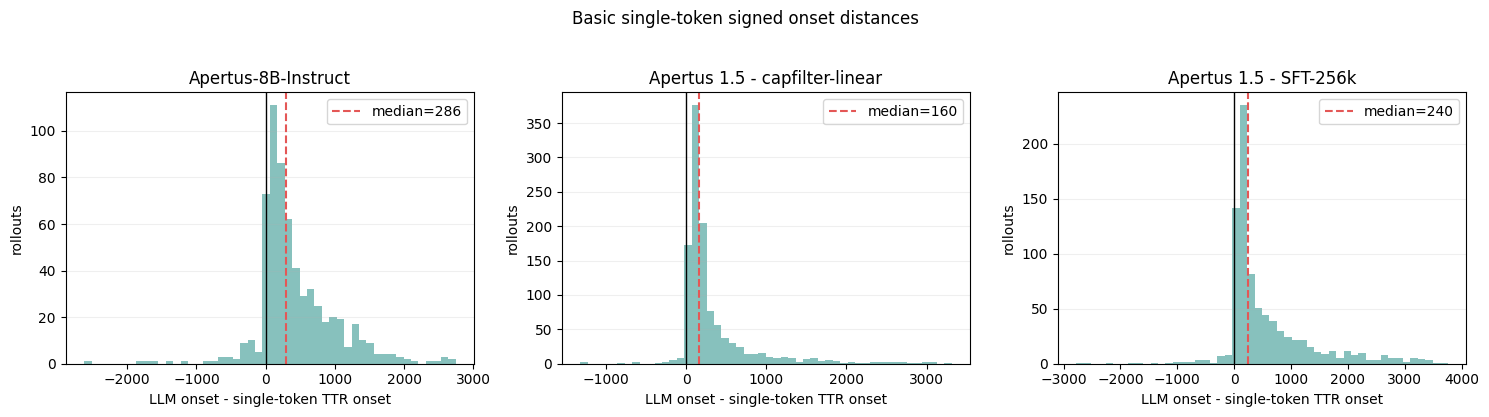

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (model, group) in zip(axes, single_onset_comparisons_df.groupby("dataset_build", sort=False)):
    values = group["signed_distance"].to_numpy()
    ax.hist(values, bins=50, color="#72b7b2", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(np.median(values), color="#e45756", linestyle="--", label=f"median={np.median(values):.0f}")
    ax.set_title(model)
    ax.set_xlabel("LLM onset - single-token TTR onset")
    ax.set_ylabel("rollouts")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Basic single-token signed onset distances", y=1.03)
plt.tight_layout()
plt.show()

## 6. Sustained run-4 TTR: onset study

This comparison is conditional on both methods providing an onset: the judge must be positive, its quote must be located, and TTR must contain a sustained four-token run. Judge-positive/TTR-negative rollouts are already counted as false negatives in the completion-level study and cannot contribute a finite onset distance.

In [15]:
onset_frames = []
onset_rows = []
for model, population in populations.items():
    comparable = population[
        population["is_degenerating"]
        & population["llm_onset"].notna()
        & population["ttr_run4_onset"].notna()
    ].copy()
    comparable["signed_distance"] = comparable["llm_onset"] - comparable["ttr_run4_onset"]
    comparable["absolute_distance"] = comparable["signed_distance"].abs()
    comparable["dataset_build"] = model
    onset_frames.append(comparable)

    d = comparable["signed_distance"]
    a = comparable["absolute_distance"]
    onset_rows.append({
        "dataset_build": model,
        "n_comparable": len(comparable),
        "mean_signed_distance": d.mean(),
        "median_signed_distance": d.median(),
        "mean_absolute_distance": a.mean(),
        "median_absolute_distance": a.median(),
        "q25_signed": d.quantile(0.25),
        "q75_signed": d.quantile(0.75),
        "judge_earlier_rate": (d < 0).mean(),
        "exact_rate": (d == 0).mean(),
        "judge_later_rate": (d > 0).mean(),
        "within_32_tokens": (a <= 32).mean(),
        "within_64_tokens": (a <= 64).mean(),
        "within_128_tokens": (a <= 128).mean(),
    })

run4_onset_comparisons_df = pd.concat(onset_frames, ignore_index=True)
run4_onset_summary_df = pd.DataFrame(onset_rows).set_index("dataset_build")
display(run4_onset_summary_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
    "q25_signed": "{:.1f}", "q75_signed": "{:.1f}",
    "judge_earlier_rate": "{:.1%}", "exact_rate": "{:.1%}",
    "judge_later_rate": "{:.1%}", "within_32_tokens": "{:.1%}",
    "within_64_tokens": "{:.1%}", "within_128_tokens": "{:.1%}",
}))

,n_comparable,mean_signed_distance,median_signed_distance,mean_absolute_distance,median_absolute_distance,q25_signed,q75_signed,judge_earlier_rate,exact_rate,judge_later_rate,within_32_tokens,within_64_tokens,within_128_tokens
dataset_build,,,,,,,,,,,,,
Apertus-8B-Instruct,622,429.1,274.0,499.2,311.0,102.0,680.5,7.1%,4.5%,88.4%,8.0%,12.7%,23.2%
Apertus 1.5 - capfilter-linear,1139,320.7,160.0,336.1,165.0,91.0,339.5,3.3%,1.6%,95.1%,8.3%,15.1%,39.2%
Apertus 1.5 - SFT-256k,846,546.3,236.5,609.4,267.0,115.2,771.8,4.8%,1.7%,93.5%,7.0%,11.6%,27.0%


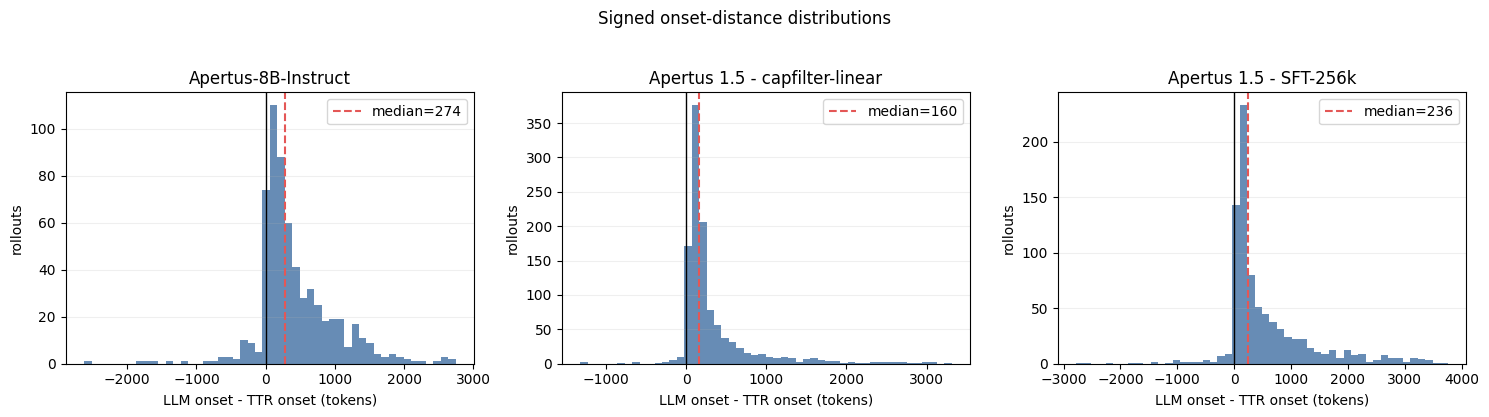

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (model, group) in zip(axes, run4_onset_comparisons_df.groupby("dataset_build", sort=False)):
    values = group["signed_distance"].to_numpy()
    ax.hist(values, bins=50, color="#4c78a8", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(np.median(values), color="#e45756", linestyle="--", label=f"median={np.median(values):.0f}")
    ax.set_title(model)
    ax.set_xlabel("LLM onset - TTR onset (tokens)")
    ax.set_ylabel("rollouts")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Signed onset-distance distributions", y=1.03)
plt.tight_layout()
plt.show()

### 6.1 Per-domain run-4 onset results

In [17]:
run4_domain_onset_df = (
    run4_onset_comparisons_df.groupby(["dataset_build", "domain"])["signed_distance"]
    .agg(
        n="size",
        mean_signed_distance="mean",
        median_signed_distance="median",
        mean_absolute_distance=lambda x: x.abs().mean(),
        median_absolute_distance=lambda x: x.abs().median(),
    )
)
display(run4_domain_onset_df.style.format({
    "mean_signed_distance": "{:.1f}", "median_signed_distance": "{:.1f}",
    "mean_absolute_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
}))

### 6.2 Largest run-4 onset disagreements

These rows are useful for qualitative inspection. A large negative value means that the LLM judge identifies a substantially earlier first occurrence of the eventual pattern; a large positive value means that the sustained TTR rule fires substantially earlier.

In [18]:
example_columns = [
    "dataset_build", "domain", "prompt_id", "rollout_idx",
    "ttr_run4_onset", "llm_onset", "signed_distance", "onset_quote",
]
largest_disagreements = (
    run4_onset_comparisons_df.assign(abs_distance=lambda d: d["signed_distance"].abs())
    .sort_values("abs_distance", ascending=False)
    [example_columns]
    .head(20)
)
display(largest_disagreements)

,dataset_build,domain,prompt_id,rollout_idx,ttr_run4_onset,llm_onset,signed_distance,onset_quote
2578,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00527,7,51.0,3802.0,3751.0,Now confirm each step carefully.
2199,Apertus 1.5 - SFT-256k,if_sft_data_verified,if_sft_data_verified_00435,5,57.0,3634.0,3577.0,"Let's try \(\alpha = \frac{\pi}{6}\), then \(\beta = \frac{\pi}{2}\) and \(\gamma = \frac{5\pi}{..."
1764,Apertus 1.5 - SFT-256k,aime_2025,aime_2025_00004,5,608.0,3998.0,3390.0,"Wait, perhaps my initial approach is wrong. Let me think again."
2550,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00444,4,157.0,3533.0,3376.0,Let's try to verify the shading.\n * Top row: Right square is shaded.\n * Middle row: ...
2393,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00010,0,358.0,3731.0,3373.0,The last number on the board is $N' = \frac{10(53^{2022}-1)}{9}$. Let's see if $N'$ can be $N$. ...
2588,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00555,5,346.0,3689.0,3343.0,"Now, we need to double-check the process: The second car traveled the first half of distance wit..."
1155,Apertus 1.5 - capfilter-linear,if_sft_data_verified,if_sft_data_verified_00490,8,436.0,3748.0,3312.0,We have f(n) = 2^n - 1.\n\nWe need to check if f(n) = 2^n - 1 satisfies the arithmetic sequence ...
2462,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00212,4,197.0,3478.0,3281.0,"Wait, let me re-calculate $M+L$ for $B=94$ again."
2164,Apertus 1.5 - SFT-256k,if_sft_data_verified,if_sft_data_verified_00367,1,541.0,3806.0,3265.0,$165/10 = 165/10$ is $165/10$.
2580,Apertus 1.5 - SFT-256k,numinamath_1_5,numinamath_1_5_00538,0,549.0,3798.0,3249.0,Let me re-calculate $AC = \frac{6 \sin 30^\circ}{\sin 70^\circ} \frac{\sin 40^\circ}{4 \sin 30^\...


## 7. Direct comparison: single-token vs. run-4

The single-token rule is logically less restrictive. Therefore every run-4 positive must also be single-token positive, and its onset cannot precede the first single threshold crossing. The checks below enforce these invariants before comparing detection and onset metrics.

In [19]:
flag_relation_rows = []
onset_delay_rows = []
for model, population in populations.items():
    assert not (population["ttr_run4_flag"] & ~population["ttr_single_flag"]).any()
    both = population["ttr_run4_flag"]
    assert (
        population.loc[both, "ttr_single_onset"]
        <= population.loc[both, "ttr_run4_onset"]
    ).all()
    flag_relation_rows.append({
        "dataset_build": model,
        "neither": int((~population["ttr_single_flag"]).sum()),
        "single_only": int((population["ttr_single_flag"] & ~population["ttr_run4_flag"]).sum()),
        "both": int(population["ttr_run4_flag"].sum()),
        "run4_only": int((population["ttr_run4_flag"] & ~population["ttr_single_flag"]).sum()),
    })
    delay = (
        population.loc[both, "ttr_run4_onset"]
        - population.loc[both, "ttr_single_onset"]
    )
    onset_delay_rows.append({
        "dataset_build": model,
        "n_both_ttr_positive": len(delay),
        "same_onset_rate": (delay == 0).mean(),
        "mean_run4_minus_single": delay.mean(),
        "median_run4_minus_single": delay.median(),
        "max_run4_minus_single": delay.max(),
    })

flag_relation_df = pd.DataFrame(flag_relation_rows).set_index("dataset_build")
onset_rule_delay_df = pd.DataFrame(onset_delay_rows).set_index("dataset_build")

comparison_metrics_df = pd.concat({
    "single-token": single_completion_metrics_df,
    "run-4": run4_completion_metrics_df,
}, names=["rule", "dataset_build"])
comparison_onset_df = pd.concat({
    "single-token": single_onset_summary_df,
    "run-4": run4_onset_summary_df,
}, names=["rule", "dataset_build"])

print("Flag relationship (run4_only must be zero) -- test split, unified population")
display(flag_relation_df)
print("Completion-level comparison (ALL domains, pooled) -- test split, unified population")
display(comparison_metrics_df[[
    "n", "tp", "fp", "fn", "tn", "precision", "recall", "specificity", "balanced_accuracy", "mcc", "accuracy",
]].style.format({
    "precision": "{:.3f}", "recall": "{:.3f}", "specificity": "{:.3f}",
    "balanced_accuracy": "{:.3f}", "mcc": "{:.3f}", "accuracy": "{:.3f}",
}))
print("Onset comparison")
display(comparison_onset_df[[
    "n_comparable", "median_signed_distance", "median_absolute_distance",
    "within_64_tokens", "within_128_tokens",
]].style.format({
    "median_signed_distance": "{:.1f}", "median_absolute_distance": "{:.1f}",
    "within_64_tokens": "{:.1%}", "within_128_tokens": "{:.1%}",
}))
print("How much later the run-4 rule fires than the first threshold crossing")
display(onset_rule_delay_df.style.format({
    "same_onset_rate": "{:.1%}", "mean_run4_minus_single": "{:.1f}",
    "median_run4_minus_single": "{:.1f}", "max_run4_minus_single": "{:.0f}",
}))


Flag relationship (run4_only must be zero) -- test split, unified population


,neither,single_only,both,run4_only
dataset_build,,,,
Apertus-8B-Instruct,194,2,631,0
Apertus 1.5 - capfilter-linear,133,0,1145,0
Apertus 1.5 - SFT-256k,201,2,908,0


Completion-level comparison (ALL domains, pooled) -- test split, unified population


Onset comparison


How much later the run-4 rule fires than the first threshold crossing


,n_both_ttr_positive,same_onset_rate,mean_run4_minus_single,median_run4_minus_single,max_run4_minus_single
dataset_build,,,,,
Apertus-8B-Instruct,631,96.0%,1.9,0.0,290
Apertus 1.5 - capfilter-linear,1145,97.7%,3.0,0.0,1604
Apertus 1.5 - SFT-256k,908,95.8%,7.1,0.0,1736


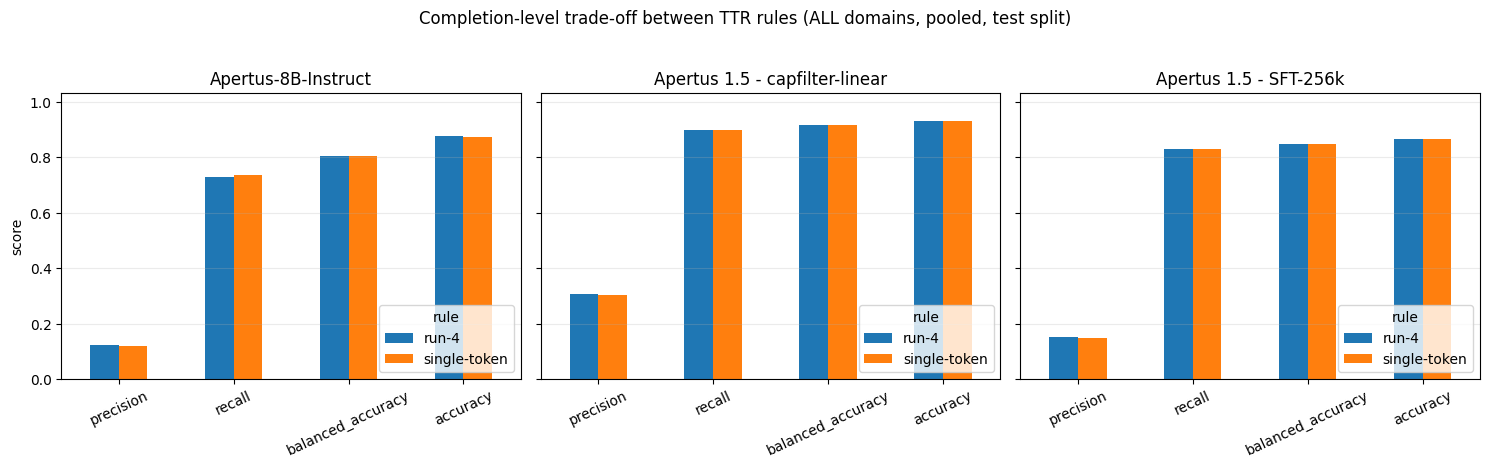

In [20]:
comparison_plot_df = (
    comparison_metrics_df[["precision", "recall", "accuracy", "balanced_accuracy"]]
    .reset_index()
    .melt(id_vars=["rule", "dataset_build"], var_name="metric", value_name="value")
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, model in zip(axes, DATASETS):
    sub = comparison_plot_df[comparison_plot_df["dataset_build"].eq(model)]
    pivot = sub.pivot(index="metric", columns="rule", values="value")
    pivot.loc[["precision", "recall", "balanced_accuracy", "accuracy"]].plot.bar(ax=ax, ylim=(0, 1.03))
    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("score")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="rule", loc="lower right")
fig.suptitle("Completion-level trade-off between TTR rules (ALL domains, pooled, test split)", y=1.03)
plt.tight_layout()
plt.show()


## 8. Single-token TTR under natural EOS versus token cap

Section 2.1's unified population already treats every `stop_reason == "eos"` rollout as a real negative on these grounds; this section is the direct evidence for that choice. It reuses `full_populations` (Section 2.1, every rollout, both terminations) and applies the tuned $\tau$ (Section 2.1) to every eligible token, separating completions that reached EOS naturally from those that exhausted the 4096-token budget.

Only finite `repetition_score` positions are eligible: the final 255 positions are `NaN` because a full forward-looking 256-token window no longer fits. A rollout is flagged when at least one eligible position has $r_t\geq\tau$. Among flagged rollouts, the table also reports how many eligible tokens are positive and what fraction of all eligible positions they represent. This is the direct TTR analogue of asking not only whether a repeat exists, but how much of the completion it occupies.


,tau,eos_n,eos_flag_rate,eos_median_positive_tokens,eos_median_positive_fraction,cap_n,cap_flag_rate,cap_median_positive_tokens,cap_median_positive_fraction
dataset_build,,,,,,,,,
Apertus-8B-Instruct,0.550000,35410,12.1%,107.0,24.8%,890,77.3%,3467.5,90.3%
Apertus 1.5 - capfilter-linear,0.650000,34952,7.0%,107.0,19.9%,1348,89.6%,3501.0,91.1%
Apertus 1.5 - SFT-256k,0.600000,35107,13.3%,118.0,21.4%,1193,82.4%,3310.0,86.2%


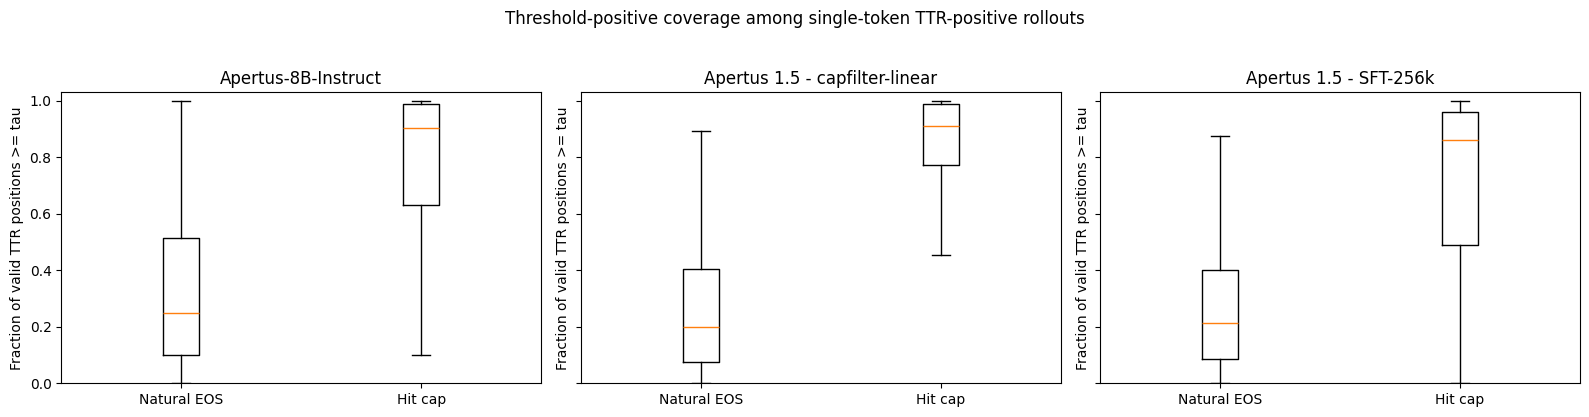

In [21]:
def token_level_ttr_stats(scores, threshold):
    values = np.asarray(scores, dtype=float)
    finite = np.isfinite(values)
    positive = finite & (values >= threshold)
    n_valid = int(finite.sum())
    n_positive = int(positive.sum())
    return {
        "n_valid_ttr_tokens": n_valid,
        "n_positive_ttr_tokens": n_positive,
        "positive_ttr_fraction": n_positive / n_valid if n_valid else np.nan,
        "ttr_single_flag": bool(n_positive),
    }


# Boundary/masking checks: NaNs are ineligible and equality at the threshold is positive.
assert token_level_ttr_stats([np.nan, 0.79, 0.8], threshold=0.8) == {
    "n_valid_ttr_tokens": 2,
    "n_positive_ttr_tokens": 1,
    "positive_ttr_fraction": 0.5,
    "ttr_single_flag": True,
}
assert token_level_ttr_stats([np.nan, 0.79], threshold=0.8)["ttr_single_flag"] is False

ttr_context_rows = []
for model, population in full_populations.items():
    tau = TAU[model]
    stats = population["repetition_score"].apply(lambda scores: token_level_ttr_stats(scores, threshold=tau))
    population = pd.concat([population, pd.DataFrame(stats.tolist(), index=population.index)], axis=1)
    population["termination"] = np.where(population["stop_reason"].eq("eos"), "Natural EOS", "Hit token cap")
    assert (population["ttr_single_flag"] == population["n_positive_ttr_tokens"].gt(0)).all()
    full_populations[model] = population  # keep the computed columns for the plot below

    for termination in ["Natural EOS", "Hit token cap"]:
        group = population[population["termination"].eq(termination)]
        flagged = group[group["ttr_single_flag"]]
        ttr_context_rows.append({
            "dataset_build": model,
            "termination": termination,
            "n_rollouts": len(group),
            "n_flagged": len(flagged),
            "flag_rate": group["ttr_single_flag"].mean(),
            "median_positive_tokens_flagged": flagged["n_positive_ttr_tokens"].median(),
            "median_positive_fraction_flagged": flagged["positive_ttr_fraction"].median(),
        })

ttr_context_long_df = pd.DataFrame(ttr_context_rows)
ttr_context_records = []
for model in DATASETS:
    eos = ttr_context_long_df[
        ttr_context_long_df["dataset_build"].eq(model)
        & ttr_context_long_df["termination"].eq("Natural EOS")
    ].iloc[0]
    cap = ttr_context_long_df[
        ttr_context_long_df["dataset_build"].eq(model)
        & ttr_context_long_df["termination"].eq("Hit token cap")
    ].iloc[0]
    ttr_context_records.append({
        "dataset_build": model,
        "tau": TAU[model],
        "eos_n": int(eos["n_rollouts"]),
        "eos_flag_rate": eos["flag_rate"],
        "eos_median_positive_tokens": eos["median_positive_tokens_flagged"],
        "eos_median_positive_fraction": eos["median_positive_fraction_flagged"],
        "cap_n": int(cap["n_rollouts"]),
        "cap_flag_rate": cap["flag_rate"],
        "cap_median_positive_tokens": cap["median_positive_tokens_flagged"],
        "cap_median_positive_fraction": cap["median_positive_fraction_flagged"],
    })

ttr_context_df = pd.DataFrame(ttr_context_records).set_index("dataset_build")
display(ttr_context_df.style.format({
    "eos_flag_rate": "{:.1%}", "cap_flag_rate": "{:.1%}",
    "eos_median_positive_tokens": "{:.1f}", "cap_median_positive_tokens": "{:.1f}",
    "eos_median_positive_fraction": "{:.1%}",
    "cap_median_positive_fraction": "{:.1%}",
}))

fig, axes = plt.subplots(1, len(DATASETS), figsize=(16, 4), sharey=True)
for ax, (model, population) in zip(axes, full_populations.items()):
    flagged = population[population["ttr_single_flag"]]
    values = [
        flagged.loc[flagged["termination"].eq(termination), "positive_ttr_fraction"]
        for termination in ["Natural EOS", "Hit token cap"]
    ]
    ax.boxplot(values, tick_labels=["Natural EOS", "Hit cap"], showfliers=False)
    ax.set_title(model)
    ax.set_ylabel("Fraction of valid TTR positions >= tau")
    ax.set_ylim(0, 1.03)
fig.suptitle("Threshold-positive coverage among single-token TTR-positive rollouts", y=1.03)
fig.tight_layout()
plt.show()


## 9. Paper-ready summary

In [22]:
summary_lines = [
    "We evaluate two TTR rules against the LLM judge on the unified population (Section 2.1): "
    "positives are judge-confirmed truncated rollouts, negatives are every natural-EOS rollout by "
    "definition plus the few judge-confirmed-negative truncated rollouts. The threshold $\\tau$ is "
    "tuned per dataset build on a calibration half of the prompts and reported on the disjoint test "
    "half only. The basic rule flags a generation after any single token with $r_t\\geq\\tau$; the "
    "sustained rule requires four consecutive threshold-positive positions. Tuned $\\tau$ per build:",
    "",
    "| Dataset build | tau |",
    "|---|---:|",
]
for model, tau in TAU.items():
    summary_lines.append(f"| {model} | {tau:.2f} |")
summary_lines.extend([
    "",
    "Completion-level results (ALL domains, pooled, test split):",
    "",
    "| Rule | Dataset build | Precision | Recall | Specificity | Bal. Acc. | MCC | Accuracy |",
    "|---|---|---:|---:|---:|---:|---:|---:|",
])
for rule, table in [("single-token", single_completion_metrics_df), ("run-4", run4_completion_metrics_df)]:
    for model, row in table.iterrows():
        summary_lines.append(
            f"| {rule} | {model} | {row['precision']:.3f} | {row['recall']:.3f} | "
            f"{row['specificity']:.3f} | {row['balanced_accuracy']:.3f} | {row['mcc']:.3f} | {row['accuracy']:.3f} |"
        )
summary_lines.extend([
    "",
    "The single-token rule is the more sensitive definition; the run-4 rule can only remove positive "
    "predictions, trading recall for protection against isolated threshold crossings. Domains below "
    "`metric_eval.MIN_POSITIVES_TEST` test-side positive rollouts are excluded from the domain-balanced "
    "macro-average (Sections 3.1, 5) -- see the per-domain tables for exactly which ones.",
    "",
    "On rollouts where the corresponding TTR rule provides an onset and the judge quote is found verbatim, the onset results are:",
    "",
    "| Rule | Dataset build | Comparable $n$ | Median signed distance | Median absolute distance |",
    "|---|---|---:|---:|---:|",
])
for rule, table in [("single-token", single_onset_summary_df), ("run-4", run4_onset_summary_df)]:
    for model, row in table.iterrows():
        summary_lines.append(
            f"| {rule} | {model} | {int(row['n_comparable'])} | {row['median_signed_distance']:.1f} tokens | {row['median_absolute_distance']:.1f} tokens |"
        )
summary_lines.extend([
    "",
    "Both TTR onset definitions remain forward-looking because each score at position $t$ summarizes the 256-token window beginning at $t$.",
    "",
    "Applying the basic single-token rule to all rollouts shows how strongly termination context changes the signal. The medians below are conditional on the rollout being flagged:",
    "",
    "| Dataset build | EOS flag rate | EOS median positive tokens (fraction) | Hit-cap flag rate | Hit-cap median positive tokens (fraction) |",
    "|---|---:|---:|---:|---:|",
])
for model in DATASETS:
    row = ttr_context_df.loc[model]
    summary_lines.append(
        f"| {model} | {row['eos_flag_rate']:.1%} | {row['eos_median_positive_tokens']:.1f} ({row['eos_median_positive_fraction']:.1%}) | "
        f"{row['cap_flag_rate']:.1%} | {row['cap_median_positive_tokens']:.1f} ({row['cap_median_positive_fraction']:.1%}) |"
    )
summary_lines.extend([
    "",
    "Natural-EOS false alarms are rare and usually occupy a limited portion of the valid TTR positions. Capped positives are much more common and, when flagged, typically remain above threshold through most of the eligible completion. This is the direct evidence for treating natural-EOS rollouts as real negatives in Section 2.1's unified population, rather than interpreting one isolated threshold crossing as equally strong evidence.",
])
display(Markdown("\n".join(summary_lines)))


We evaluate two TTR rules against the LLM judge on the unified population (Section 2.1): positives are judge-confirmed truncated rollouts, negatives are every natural-EOS rollout by definition plus the few judge-confirmed-negative truncated rollouts. The threshold $\tau$ is tuned per dataset build on a calibration half of the prompts and reported on the disjoint test half only. The basic rule flags a generation after any single token with $r_t\geq\tau$; the sustained rule requires four consecutive threshold-positive positions. Tuned $\tau$ per build:

| Dataset build | tau |
|---|---:|
| Apertus-8B-Instruct | 0.55 |
| Apertus 1.5 - capfilter-linear | 0.65 |
| Apertus 1.5 - SFT-256k | 0.60 |

Completion-level results (ALL domains, pooled, test split):

| Rule | Dataset build | Precision | Recall | Specificity | Bal. Acc. | MCC | Accuracy |
|---|---|---:|---:|---:|---:|---:|---:|
| single-token | Apertus-8B-Instruct | 0.119 | 0.734 | 0.877 | 0.805 | 0.262 | 0.874 |
| single-token | Apertus 1.5 - capfilter-linear | 0.304 | 0.898 | 0.930 | 0.914 | 0.498 | 0.929 |
| single-token | Apertus 1.5 - SFT-256k | 0.148 | 0.830 | 0.866 | 0.848 | 0.315 | 0.865 |
| run-4 | Apertus-8B-Instruct | 0.121 | 0.729 | 0.880 | 0.804 | 0.264 | 0.876 |
| run-4 | Apertus 1.5 - capfilter-linear | 0.308 | 0.898 | 0.931 | 0.915 | 0.502 | 0.930 |
| run-4 | Apertus 1.5 - SFT-256k | 0.150 | 0.828 | 0.868 | 0.848 | 0.317 | 0.867 |

The single-token rule is the more sensitive definition; the run-4 rule can only remove positive predictions, trading recall for protection against isolated threshold crossings. Domains below `metric_eval.MIN_POSITIVES_TEST` test-side positive rollouts are excluded from the domain-balanced macro-average (Sections 3.1, 5) -- see the per-domain tables for exactly which ones.

On rollouts where the corresponding TTR rule provides an onset and the judge quote is found verbatim, the onset results are:

| Rule | Dataset build | Comparable $n$ | Median signed distance | Median absolute distance |
|---|---|---:|---:|---:|
| single-token | Apertus-8B-Instruct | 624 | 286.0 tokens | 314.0 tokens |
| single-token | Apertus 1.5 - capfilter-linear | 1139 | 160.0 tokens | 165.0 tokens |
| single-token | Apertus 1.5 - SFT-256k | 848 | 240.5 tokens | 270.5 tokens |
| run-4 | Apertus-8B-Instruct | 622 | 274.0 tokens | 311.0 tokens |
| run-4 | Apertus 1.5 - capfilter-linear | 1139 | 160.0 tokens | 165.0 tokens |
| run-4 | Apertus 1.5 - SFT-256k | 846 | 236.5 tokens | 267.0 tokens |

Both TTR onset definitions remain forward-looking because each score at position $t$ summarizes the 256-token window beginning at $t$.

Applying the basic single-token rule to all rollouts shows how strongly termination context changes the signal. The medians below are conditional on the rollout being flagged:

| Dataset build | EOS flag rate | EOS median positive tokens (fraction) | Hit-cap flag rate | Hit-cap median positive tokens (fraction) |
|---|---:|---:|---:|---:|
| Apertus-8B-Instruct | 12.1% | 107.0 (24.8%) | 77.3% | 3467.5 (90.3%) |
| Apertus 1.5 - capfilter-linear | 7.0% | 107.0 (19.9%) | 89.6% | 3501.0 (91.1%) |
| Apertus 1.5 - SFT-256k | 13.3% | 118.0 (21.4%) | 82.4% | 3310.0 (86.2%) |

Natural-EOS false alarms are rare and usually occupy a limited portion of the valid TTR positions. Capped positives are much more common and, when flagged, typically remain above threshold through most of the eligible completion. This is the direct evidence for treating natural-EOS rollouts as real negatives in Section 2.1's unified population, rather than interpreting one isolated threshold crossing as equally strong evidence.

## 10. Interpretation notes

- Completion-level detection (Sections 3, 5) now uses the unified population (Section 2.1): positives from judge-confirmed truncated rollouts, negatives from every natural-EOS rollout plus the few judge-confirmed-negative truncated rows. Specificity is meaningful now, not just reported for completeness -- an earlier version of this notebook evaluated only on truncated rollouts, where negatives were scarce and specificity was correspondingly unstable.
- $\tau$ is tuned per dataset build (Section 2.1, calibration half only) rather than fixed at 0.8 a priori, and reported on the disjoint test half. The tuned value differs somewhat across dataset builds -- see Section 9's table.
- Onset comparisons (Sections 6, 7) still use the truncated-only, judge-quote-matched population, since onset distance is only defined where the judge locates a quote; that population and its "different denominators" caveat are unchanged from an earlier version of this notebook.
- Per-domain rows (Sections 3.2, 5) show `n`/TP/FP/FN/TN next to every metric and flag domains below `metric_eval.MIN_POSITIVES_TEST` positive test rollouts as `insufficient`; these are reported but excluded from the domain-balanced macro-average, never silently pooled in a way that lets a large domain dominate.
- The TTR label at position $t$ summarizes the 256-token window starting at $t$. Therefore, the TTR onset is a forward-looking warning position, whereas the judge is instructed to mark the first occurrence of the pattern that later repeats.
- The single-token rule follows the simplest interpretation of a token-level label and maximizes sensitivity. The run-4 rule removes isolated spikes but does not guarantee semantic degeneration. Both use the same tuned $\tau$, varying only the persistence window, so $y_4\Rightarrow y_1$ still holds exactly.
- Failed judge calls and judge-positive rows without a verifiably locatable quote are reported as coverage losses, not silently treated as negative labels.
- Section 8 is the direct evidence for treating natural-EOS rollouts as real negatives (Section 2.1): a threshold crossing is rare under natural EOS and, when it occurs, is usually a short, incidental stretch, whereas a long threshold-positive region in a capped rollout is common and covers most of the eligible completion.
